In [1]:
# Chargement de churn_features depuis BigQuery — la SEULE table que le ML est autorisé à lire (ADR-009)
import pandas as pd

PROJECT_ID = "starlit-gift-504722-c7"
query = """
    SELECT *
    FROM `starlit-gift-504722-c7.lumievre_marts.churn_features`
"""
df = pd.read_gbq(query, project_id=PROJECT_ID)
print(df.shape)
df.head()

C:\Users\Moi\AppData\Local\Temp\ipykernel_16868\3846845496.py:9: FutureWarning: read_gbq is deprecated and will be removed in a future version. Please use pandas_gbq.read_gbq instead: https://pandas-gbq.readthedocs.io/en/latest/api.html#pandas_gbq.read_gbq
  df = pd.read_gbq(query, project_id=PROJECT_ID)


(2329, 17)


,customer_id,recency,frequency,monetary,r_score,f_score,m_score,rfm_score,nb_tickets,low_satisfaction,loyalty_tier,preferred_channel,consent_email,nb_sends,ever_opened,ever_converted,churned
0,17804,194,3,385.230000000,1,1,1,3,0,False,Bronze,email,True,3,True,False,True
1,13442,485,3,419.870000000,1,1,1,3,2,False,Silver,email,True,2,False,False,True
2,17167,197,3,867.110000000,1,1,1,3,1,False,Gold,email,False,4,True,False,True
3,15331,317,3,767.910000000,1,1,1,3,0,False,Silver,email,True,4,True,False,True
4,17185,409,3,229.460000000,1,1,1,3,0,False,Silver,email,False,4,True,False,True


In [2]:
# Vue d'ensemble : équilibre des classes, types de colonnes
print(df["churned"].value_counts(normalize=True))
print()
df.info()

churned
False    0.708459
True     0.291541
Name: proportion, dtype: Float64

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2329 entries, 0 to 2328
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customer_id        2329 non-null   Int64  
 1   recency            2329 non-null   Int64  
 2   frequency          2329 non-null   Int64  
 3   monetary           2329 non-null   object 
 4   r_score            2329 non-null   Int64  
 5   f_score            2329 non-null   Int64  
 6   m_score            2329 non-null   Int64  
 7   rfm_score          2329 non-null   Int64  
 8   nb_tickets         2329 non-null   Int64  
 9   low_satisfaction   2329 non-null   boolean
 10  loyalty_tier       2329 non-null   object 
 11  preferred_channel  2329 non-null   object 
 12  consent_email      2329 non-null   boolean
 13  nb_sends           2329 non-null   Int64  
 14  ever_opened        2329 non-null   boolean

In [3]:
# Correction du type NUMERIC -> float64
df["monetary"] = df["monetary"].astype("float64")

# Encodage des variables catégorielles (loyalty_tier, preferred_channel)
df_encoded = pd.get_dummies(df, columns=["loyalty_tier", "preferred_channel"], drop_first=True)

# Conversion des booléens nullable en booléens classiques (0/1)
bool_cols = ["low_satisfaction", "consent_email", "ever_opened", "ever_converted", "churned"]
for col in bool_cols:
    df_encoded[col] = df_encoded[col].astype(bool).astype(int)

print(df_encoded.shape)
df_encoded.dtypes

(2329, 21)


customer_id                   Int64
recency                       Int64
frequency                     Int64
monetary                    float64
r_score                       Int64
f_score                       Int64
m_score                       Int64
rfm_score                     Int64
nb_tickets                    Int64
low_satisfaction              int32
consent_email                 int32
nb_sends                      Int64
ever_opened                   int32
ever_converted                int32
churned                       int32
loyalty_tier_Gold              bool
loyalty_tier_Silver            bool
loyalty_tier_aucun             bool
preferred_channel_none         bool
preferred_channel_postal       bool
preferred_channel_sms          bool
dtype: object

In [4]:
from sklearn.model_selection import train_test_split

feature_cols = [c for c in df_encoded.columns if c not in ["customer_id", "churned"]]
X = df_encoded[feature_cols]
y = df_encoded["churned"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train :", X_train.shape, "- % churn :", y_train.mean().round(3))
print("Test  :", X_test.shape, "- % churn :", y_test.mean().round(3))

Train : (1863, 19) - % churn : 0.291
Test  : (466, 19) - % churn : 0.292


In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Standardisation : indispensable pour la régression logistique (les variables
# n'ont pas la même échelle, ex: monetary en centaines/milliers vs des 0/1)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

print("Modèle entraîné sur", X_train.shape[0], "clients")

Modèle entraîné sur 1863 clients


In [6]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

y_pred = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred))
print("AUC-ROC :", round(roc_auc_score(y_test, y_proba), 3))
print()
print("Matrice de confusion :")
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.79      0.90      0.84       330
           1       0.63      0.42      0.50       136

    accuracy                           0.76       466
   macro avg       0.71      0.66      0.67       466
weighted avg       0.74      0.76      0.74       466

AUC-ROC : 0.791

Matrice de confusion :
[[297  33]
 [ 79  57]]


In [7]:
from sklearn.metrics import precision_recall_curve

precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)

# On cherche le seuil le plus haut qui donne encore au moins 70% de recall
# (seuil haut = moins de faux positifs, à recall égal)
target_recall = 0.70
valid = recalls[:-1] >= target_recall
best_idx = thresholds[valid].argmax() if valid.any() else None

if best_idx is not None:
    best_threshold = thresholds[valid][best_idx]
    print(f"Seuil retenu : {best_threshold:.3f}")
    print(f"Recall obtenu : {recalls[:-1][valid][best_idx]:.3f}")
    print(f"Précision obtenue : {precisions[:-1][valid][best_idx]:.3f}")
else:
    print("Aucun seuil n'atteint 70% de recall")

Seuil retenu : 0.265
Recall obtenu : 0.706
Précision obtenue : 0.525


In [8]:
y_pred_adjusted = (y_proba >= 0.265).astype(int)
print(confusion_matrix(y_test, y_pred_adjusted))
print()
print(f"Sur les {y_test.sum()} vrais churners du test, on en détecte {((y_pred_adjusted==1) & (y_test==1)).sum()}")
print(f"On contacte {y_pred_adjusted.sum()} clients au total, dont {((y_pred_adjusted==1) & (y_test==0)).sum()} qui n'allaient pas churner")

[[243  87]
 [ 41  95]]

Sur les 136 vrais churners du test, on en détecte 95
On contacte 182 clients au total, dont 87 qui n'allaient pas churner


In [9]:
# Baseline : la règle déjà en production, "à_risque_critique" = prédit churn
test_idx = X_test.index
baseline_pred = (df.loc[test_idx, "rfm_score"] <= 5).astype(int)  # correspond au segment à_risque_critique

from sklearn.metrics import precision_score, recall_score

print("--- Baseline (règle RFM déjà en production) ---")
print(f"Recall    : {recall_score(y_test, baseline_pred):.3f}")
print(f"Précision : {precision_score(y_test, baseline_pred):.3f}")

print()
print("--- Modèle ML (seuil ajusté à 0.265) ---")
print(f"Recall    : {recall_score(y_test, y_pred_adjusted):.3f}")
print(f"Précision : {precision_score(y_test, y_pred_adjusted):.3f}")

--- Baseline (règle RFM déjà en production) ---
Recall    : 0.500
Précision : 0.544

--- Modèle ML (seuil ajusté à 0.265) ---
Recall    : 0.699
Précision : 0.522


In [10]:
import mlflow

mlflow.set_experiment("lumievre_churn_baseline")

with mlflow.start_run(run_name="logistic_regression_v1"):
    mlflow.log_param("model_type", "LogisticRegression")
    mlflow.log_param("threshold", 0.265)
    mlflow.log_param("n_features", X_train.shape[1])

    mlflow.log_metric("recall", recall_score(y_test, y_pred_adjusted))
    mlflow.log_metric("precision", precision_score(y_test, y_pred_adjusted))
    mlflow.log_metric("auc_roc", roc_auc_score(y_test, y_proba))
    mlflow.log_metric("baseline_rfm_recall", recall_score(y_test, baseline_pred))
    mlflow.log_metric("baseline_rfm_precision", precision_score(y_test, baseline_pred))

    print("Run enregistré dans MLflow")

2026/08/12 01:16:26 INFO mlflow.tracking.fluent: Experiment with name 'lumievre_churn_baseline' does not exist. Creating a new experiment.


Run enregistré dans MLflow


In [11]:
from sklearn.ensemble import RandomForestClassifier

# Random Forest n'a pas besoin de standardisation (contrairement à la régression logistique)
rf_model = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42, class_weight="balanced")
rf_model.fit(X_train, y_train)

y_proba_rf = rf_model.predict_proba(X_test)[:, 1]
print("AUC-ROC Random Forest :", round(roc_auc_score(y_test, y_proba_rf), 3))

AUC-ROC Random Forest : 0.798


In [12]:
precisions_rf, recalls_rf, thresholds_rf = precision_recall_curve(y_test, y_proba_rf)

valid_rf = recalls_rf[:-1] >= target_recall
best_idx_rf = thresholds_rf[valid_rf].argmax() if valid_rf.any() else None

if best_idx_rf is not None:
    best_threshold_rf = thresholds_rf[valid_rf][best_idx_rf]
    print(f"Seuil retenu : {best_threshold_rf:.3f}")
    print(f"Recall obtenu : {recalls_rf[:-1][valid_rf][best_idx_rf]:.3f}")
    print(f"Précision obtenue : {precisions_rf[:-1][valid_rf][best_idx_rf]:.3f}")
else:
    print("Aucun seuil n'atteint 70% de recall")

Seuil retenu : 0.512
Recall obtenu : 0.706
Précision obtenue : 0.536


In [13]:
from sklearn.model_selection import cross_val_score

scores_lr = cross_val_score(
    LogisticRegression(max_iter=1000, random_state=42),
    scaler.fit_transform(X), y, cv=5, scoring="roc_auc"
)
scores_rf = cross_val_score(
    RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42, class_weight="balanced"),
    X, y, cv=5, scoring="roc_auc"
)

print(f"Régression logistique : {scores_lr.mean():.3f} (+/- {scores_lr.std():.3f})")
print(f"Random Forest         : {scores_rf.mean():.3f} (+/- {scores_rf.std():.3f})")

Régression logistique : 0.887 (+/- 0.063)
Random Forest         : 0.398 (+/- 0.374)


<Axes: title={'center': "rfm_score dans l'ordre du DataFrame"}>

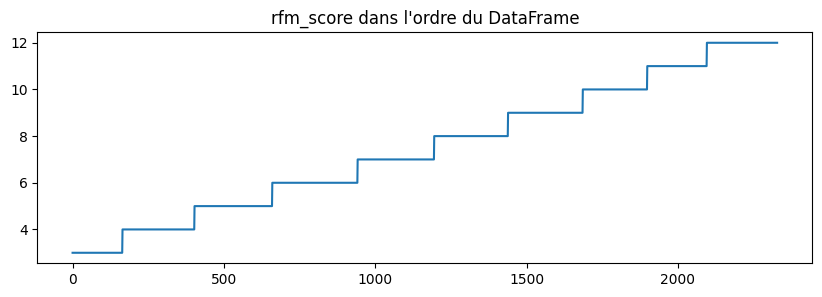

In [14]:
df_encoded["rfm_score"].plot(figsize=(10, 3), title="rfm_score dans l'ordre du DataFrame")

In [15]:
from sklearn.model_selection import StratifiedKFold

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores_lr = cross_val_score(
    LogisticRegression(max_iter=1000, random_state=42),
    scaler.fit_transform(X), y, cv=cv_strategy, scoring="roc_auc"
)
scores_rf = cross_val_score(
    RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42, class_weight="balanced"),
    X, y, cv=cv_strategy, scoring="roc_auc"
)

print(f"Régression logistique : {scores_lr.mean():.3f} (+/- {scores_lr.std():.3f})")
print(f"Random Forest         : {scores_rf.mean():.3f} (+/- {scores_rf.std():.3f})")

Régression logistique : 0.785 (+/- 0.028)
Random Forest         : 0.787 (+/- 0.023)
